In [1]:
#basic Libraries
import numpy as np
import pandas as pd
import seaborn as sb
from sklearn import svm
from sklearn.metrics import confusion_matrix,accuracy_score
from sklearn.metrics import explained_variance_score, mean_squared_error, r2_score
import matplotlib.pyplot as plt # we only need pyplot
sb.set() # set the default Seaborn style for graphics
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score

# Libraries used for Modelling
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.linear_model import LinearRegression
import xgboost as xgb
from xgboost import plot_importance
from xgboost import plot_tree
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.tree import export_graphviz

In [2]:
import warnings
import pandas as pd

warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

## Importing Dataset

The dataset,  which is in csv format, is named 'listings.csv'. Based on the work done during Exploratory Analysis, we have concluded that the predictor variables that might have the greatest impact on price are:
- Room Type
- Property Type
- Number of Bedrooms
- Amenities
- Number of Reviews

As such, we single out these variables (together with price) to form a new dataframe.

In [3]:
listingDF =  pd.read_csv('../data/listings.csv')

In [4]:
newListingsDF = listingDF[['room_type','property_type','bedrooms','amenities','number_of_reviews', 'price']]
newListingsDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3818 entries, 0 to 3817
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   room_type          3818 non-null   object 
 1   property_type      3817 non-null   object 
 2   bedrooms           3812 non-null   float64
 3   amenities          3818 non-null   object 
 4   number_of_reviews  3818 non-null   int64  
 5   price              3818 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 179.1+ KB


Data Cleaning

###  Amenities
- Displays the different types of amenities available for each listing

To clean the data in this variable:
- Checking and listing down all the different amenities that were offered
- Creating a dedicated binary column (1 = listing has it, 0 = it does not) for each amenity or group of similar amenities

**Note:** the amenity names must match the exact names used in this 2016 Seattle dataset (e.g. `Air Conditioning`, `Family/Kid Friendly`, `Free Parking on Premises`). The dataset contains 41 distinct amenities, printed below.

In [5]:
#creating a set of all possible amenities
amenities_list = list(newListingsDF.amenities)
amenities_list_string = " ".join(amenities_list)
amenities_list_string = amenities_list_string.replace('{', '')
amenities_list_string = amenities_list_string.replace('}', ',')
amenities_list_string = amenities_list_string.replace('"', '')
amenities_set = [x.strip() for x in amenities_list_string.split(',')]
amenities_set = set(amenities_set)

print("Number of distinct amenities :", len(amenities_set - {''}))
print(sorted(amenities_set - {''}))

Number of distinct amenities : 41
['24-Hour Check-in', 'Air Conditioning', 'Breakfast', 'Buzzer/Wireless Intercom', 'Cable TV', 'Carbon Monoxide Detector', 'Cat(s)', 'Dog(s)', 'Doorman', 'Dryer', 'Elevator in Building', 'Essentials', 'Family/Kid Friendly', 'Fire Extinguisher', 'First Aid Kit', 'Free Parking on Premises', 'Gym', 'Hair Dryer', 'Hangers', 'Heating', 'Hot Tub', 'Indoor Fireplace', 'Internet', 'Iron', 'Kitchen', 'Laptop Friendly Workspace', 'Lock on Bedroom Door', 'Other pet(s)', 'Pets Allowed', 'Pets live on this property', 'Pool', 'Safety Card', 'Shampoo', 'Smoke Detector', 'Smoking Allowed', 'Suitable for Events', 'TV', 'Washer', 'Washer / Dryer', 'Wheelchair Accessible', 'Wireless Internet']


In [6]:
#creating a binary column for each amenity (or group of similar amenities)
#the patterns match the amenity names used in this dataset
amenity_patterns = {
    'check_in_24h':          '24-Hour Check-in',
    'air_conditioning':      'Air Conditioning',
    'breakfast':             'Breakfast',
    'tv':                    'TV',                        #also matches 'Cable TV'
    'white_goods':           'Washer|Dryer',
    'kitchen':               'Kitchen',
    'elevator':              'Elevator in Building',
    'gym':                   'Gym',
    'child_friendly':        'Family/Kid Friendly',
    'parking':               'Free Parking on Premises',
    'hot_tub_sauna_or_pool': 'Hot Tub|Pool',
    'internet':              'Internet',                  #also matches 'Wireless Internet'
    'pets_allowed':          'Pets Allowed',
    'doorman':               'Doorman',
    'fireplace':             'Indoor Fireplace',
    'laptop_workspace':      'Laptop Friendly Workspace',
    'accessible':            'Wheelchair Accessible',
    'smoking_allowed':       'Smoking Allowed',
    'event_suitable':        'Suitable for Events',
}

newListingsDF = newListingsDF.copy()
for column, pattern in amenity_patterns.items():
    newListingsDF[column] = newListingsDF['amenities'].str.contains(pattern).astype(int)

#share of listings that have each amenity (a share of 0 would mean the pattern matched nothing)
newListingsDF[list(amenity_patterns)].mean().round(3).sort_values(ascending=False)

internet                 0.967
kitchen                  0.897
white_goods              0.821
tv                       0.718
parking                  0.568
child_friendly           0.514
fireplace                0.232
elevator                 0.206
laptop_workspace         0.195
air_conditioning         0.177
check_in_24h             0.161
pets_allowed             0.124
gym                      0.116
hot_tub_sauna_or_pool    0.086
accessible               0.079
breakfast                0.076
event_suitable           0.055
doorman                  0.022
smoking_allowed          0.021
dtype: float64

In [7]:
#dropping the original amenities variable
newListingsDF.drop('amenities', axis=1, inplace=True)

In [8]:
#removing any amenity column that no listing has
newListingsDF = newListingsDF.loc[:, (newListingsDF != 0).any()]
newListingsDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3818 entries, 0 to 3817
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   room_type              3818 non-null   object 
 1   property_type          3817 non-null   object 
 2   bedrooms               3812 non-null   float64
 3   number_of_reviews      3818 non-null   int64  
 4   price                  3818 non-null   object 
 5   check_in_24h           3818 non-null   int64  
 6   air_conditioning       3818 non-null   int64  
 7   breakfast              3818 non-null   int64  
 8   tv                     3818 non-null   int64  
 9   white_goods            3818 non-null   int64  
 10  kitchen                3818 non-null   int64  
 11  elevator               3818 non-null   int64  
 12  gym                    3818 non-null   int64  
 13  child_friendly         3818 non-null   int64  
 14  parking                3818 non-null   int64  
 15  hot_

### Property Type
- Displays the property type of a listing

To clean the data in this variable: 
- Grouping property types whose low counts might be insignificant and not provide us with enough information
- Thus, grouping property types that have counts that are < 30

In [9]:
newListingsDF.head()

,room_type,property_type,bedrooms,number_of_reviews,price,check_in_24h,air_conditioning,breakfast,tv,white_goods,...,parking,hot_tub_sauna_or_pool,internet,pets_allowed,doorman,fireplace,laptop_workspace,accessible,smoking_allowed,event_suitable
0,Entire home/apt,Apartment,1.0,207,$85.00,0,1,0,1,1,...,0,0,1,0,0,0,0,0,0,0
1,Entire home/apt,Apartment,1.0,43,$150.00,0,0,0,1,1,...,1,0,1,0,0,0,0,0,0,0
2,Entire home/apt,House,5.0,20,$975.00,0,1,0,1,1,...,1,1,1,1,0,1,0,0,0,0
3,Entire home/apt,Apartment,0.0,0,$100.00,0,0,0,0,1,...,0,0,1,0,0,1,0,0,0,0
4,Entire home/apt,House,3.0,38,$450.00,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,0


In [10]:
#checking to see the total number of each type of property 
newListingsDF.property_type.value_counts()

property_type
House              1733
Apartment          1708
Townhouse           118
Condominium          91
Loft                 40
Bed & Breakfast      37
Other                22
Cabin                21
Camper/RV            13
Bungalow             13
Boat                  8
Tent                  5
Treehouse             3
Dorm                  2
Chalet                2
Yurt                  1
Name: count, dtype: int64

In [11]:
#grouping property types with less than <30 count into 'Other'
newListingsDF.loc[~newListingsDF.property_type.isin(['House', 'Apartment','Townhouse','Condominium','Loft',"Bed & Breakfast"]), 'property_type'] = 'Other'
newListingsDF.property_type.value_counts()

property_type
House              1733
Apartment          1708
Townhouse           118
Other                91
Condominium          91
Loft                 40
Bed & Breakfast      37
Name: count, dtype: int64

### Price
- Displays the price/cost of a listing

To clean the data in this variable: 
- Since the Price variable is currently a string (with the "$" symbol), the variable is thus converted into an integer 

In [12]:
newListingsDF.price = newListingsDF.price.str[1:-3]
newListingsDF.price = newListingsDF.price.str.replace(",", "")
newListingsDF.price = newListingsDF.price.astype('int64')
newListingsDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3818 entries, 0 to 3817
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   room_type              3818 non-null   object 
 1   property_type          3818 non-null   object 
 2   bedrooms               3812 non-null   float64
 3   number_of_reviews      3818 non-null   int64  
 4   price                  3818 non-null   int64  
 5   check_in_24h           3818 non-null   int64  
 6   air_conditioning       3818 non-null   int64  
 7   breakfast              3818 non-null   int64  
 8   tv                     3818 non-null   int64  
 9   white_goods            3818 non-null   int64  
 10  kitchen                3818 non-null   int64  
 11  elevator               3818 non-null   int64  
 12  gym                    3818 non-null   int64  
 13  child_friendly         3818 non-null   int64  
 14  parking                3818 non-null   int64  
 15  hot_

Ensuring that there are no NULL entries in the data

In [13]:
#to convert NaN values to 0 for preparation for Modelling
newListingsDF = newListingsDF.fillna(0)
#checking to ensure that there are no NULL entries
newListingsDF.isnull().sum()

room_type                0
property_type            0
bedrooms                 0
number_of_reviews        0
price                    0
check_in_24h             0
air_conditioning         0
breakfast                0
tv                       0
white_goods              0
kitchen                  0
elevator                 0
gym                      0
child_friendly           0
parking                  0
hot_tub_sauna_or_pool    0
internet                 0
pets_allowed             0
doorman                  0
fireplace                0
laptop_workspace         0
accessible               0
smoking_allowed          0
event_suitable           0
dtype: int64

## Regression Models

We will use regression models to help predict the price based on the significant predictor variables identified in Exploratory Analysis.
> - **Predictor Variables**: Room_type, Property_type, Bedrooms, Number_of_Reviews, Amenities
> - **Response Variable**: Price

The following regression models will be carried out:

- Linear Regression
- Ridge Regression
- Lasso Regression
- Random Forest Regression
- XGBoost
- CatBoost

### Data Preparation
The following will be done to the data to ensure its fit into the different regression models:
- Encoding the categorical variables so that it can be fit into the regression models
- Separating the data into predictor and response variables
- Separating the data into training and testing sets (Training Sets: Testing Sets = 80% : 20%)

In [14]:
#one-hot encode the Categorial variables
transformedDF = pd.get_dummies(newListingsDF, columns=['room_type','property_type'])

#renaming some categories to remove '/' and blank spaces
newTransformedDF = transformedDF.rename(columns={'room_type_Entire home/apt': 'room_type_Entire_home_apt'})
newTransformedDF =newTransformedDF.rename(columns={'room_type_Private room': 'room_type_Private_room'})
newTransformedDF =newTransformedDF.rename(columns={'room_type_Shared room': 'room_type_Shared_room'})
newTransformedDF =newTransformedDF.rename(columns={'property_type_Bed & Breakfast': 'property_type_Bed_and_Breakfast'})

newTransformedDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3818 entries, 0 to 3817
Data columns (total 32 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   bedrooms                         3818 non-null   float64
 1   number_of_reviews                3818 non-null   int64  
 2   price                            3818 non-null   int64  
 3   check_in_24h                     3818 non-null   int64  
 4   air_conditioning                 3818 non-null   int64  
 5   breakfast                        3818 non-null   int64  
 6   tv                               3818 non-null   int64  
 7   white_goods                      3818 non-null   int64  
 8   kitchen                          3818 non-null   int64  
 9   elevator                         3818 non-null   int64  
 10  gym                              3818 non-null   int64  
 11  child_friendly                   3818 non-null   int64  
 12  parking             

In [15]:
#separating X and y for Modelling
X = newTransformedDF.drop(columns=['price']).astype(float) #Predictor Variables
y = pd.DataFrame(newTransformedDF["price"]) #Response Variables

print("Number of predictor variables :", X.shape[1])
print(list(X.columns))

Number of predictor variables : 31
['bedrooms', 'number_of_reviews', 'check_in_24h', 'air_conditioning', 'breakfast', 'tv', 'white_goods', 'kitchen', 'elevator', 'gym', 'child_friendly', 'parking', 'hot_tub_sauna_or_pool', 'internet', 'pets_allowed', 'doorman', 'fireplace', 'laptop_workspace', 'accessible', 'smoking_allowed', 'event_suitable', 'room_type_Entire_home_apt', 'room_type_Private_room', 'room_type_Shared_room', 'property_type_Apartment', 'property_type_Bed_and_Breakfast', 'property_type_Condominium', 'property_type_House', 'property_type_Loft', 'property_type_Other', 'property_type_Townhouse']


In [16]:
#splitting into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#scaling: the scaler is fitted on the training set only, so no information from the test set leaks into training
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)

### Model 1: Linear Regression


In [17]:
#creating and fitting the model
linreg = LinearRegression()     
linreg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
#coefficients of the Linear Regression line
print('Intercept of Regression \t: b = ', linreg.intercept_)
print()

#print the Coefficients against Predictors
print(pd.DataFrame(list(zip(X_train.columns, linreg.coef_[0])), columns = ["Predictors", "Coefficients"]))
print()

Intercept of Regression 	: b =  [128.42010478]

                         Predictors  Coefficients
0                          bedrooms     49.836978
1                 number_of_reviews     -3.985218
2                      check_in_24h     -4.180808
3                  air_conditioning      3.737692
4                         breakfast     -0.826651
5                                tv      1.649247
6                       white_goods      0.333785
7                           kitchen     -0.621814
8                          elevator      7.862037
9                               gym      1.193406
10                   child_friendly     -0.817935
11                          parking     -4.399820
12            hot_tub_sauna_or_pool      5.119360
13                         internet     -1.742990
14                     pets_allowed     -1.408933
15                          doorman      5.095309
16                        fireplace      3.155878
17                 laptop_workspace     -1.016791
18

**Note that**:
A positive coefficient indicates that as the predictor variable increases, the response variable also increases. 
A negative coefficient indicates that as the predictor variable increases, the response variable decreases.

In [19]:
#predict Response corresponding to Predictors
trainPredictionLR = linreg.predict(X_train)
testPredictionLR = linreg.predict(X_test)

Text(0, 0.5, 'Predicted values of the Response Variable (Test)')

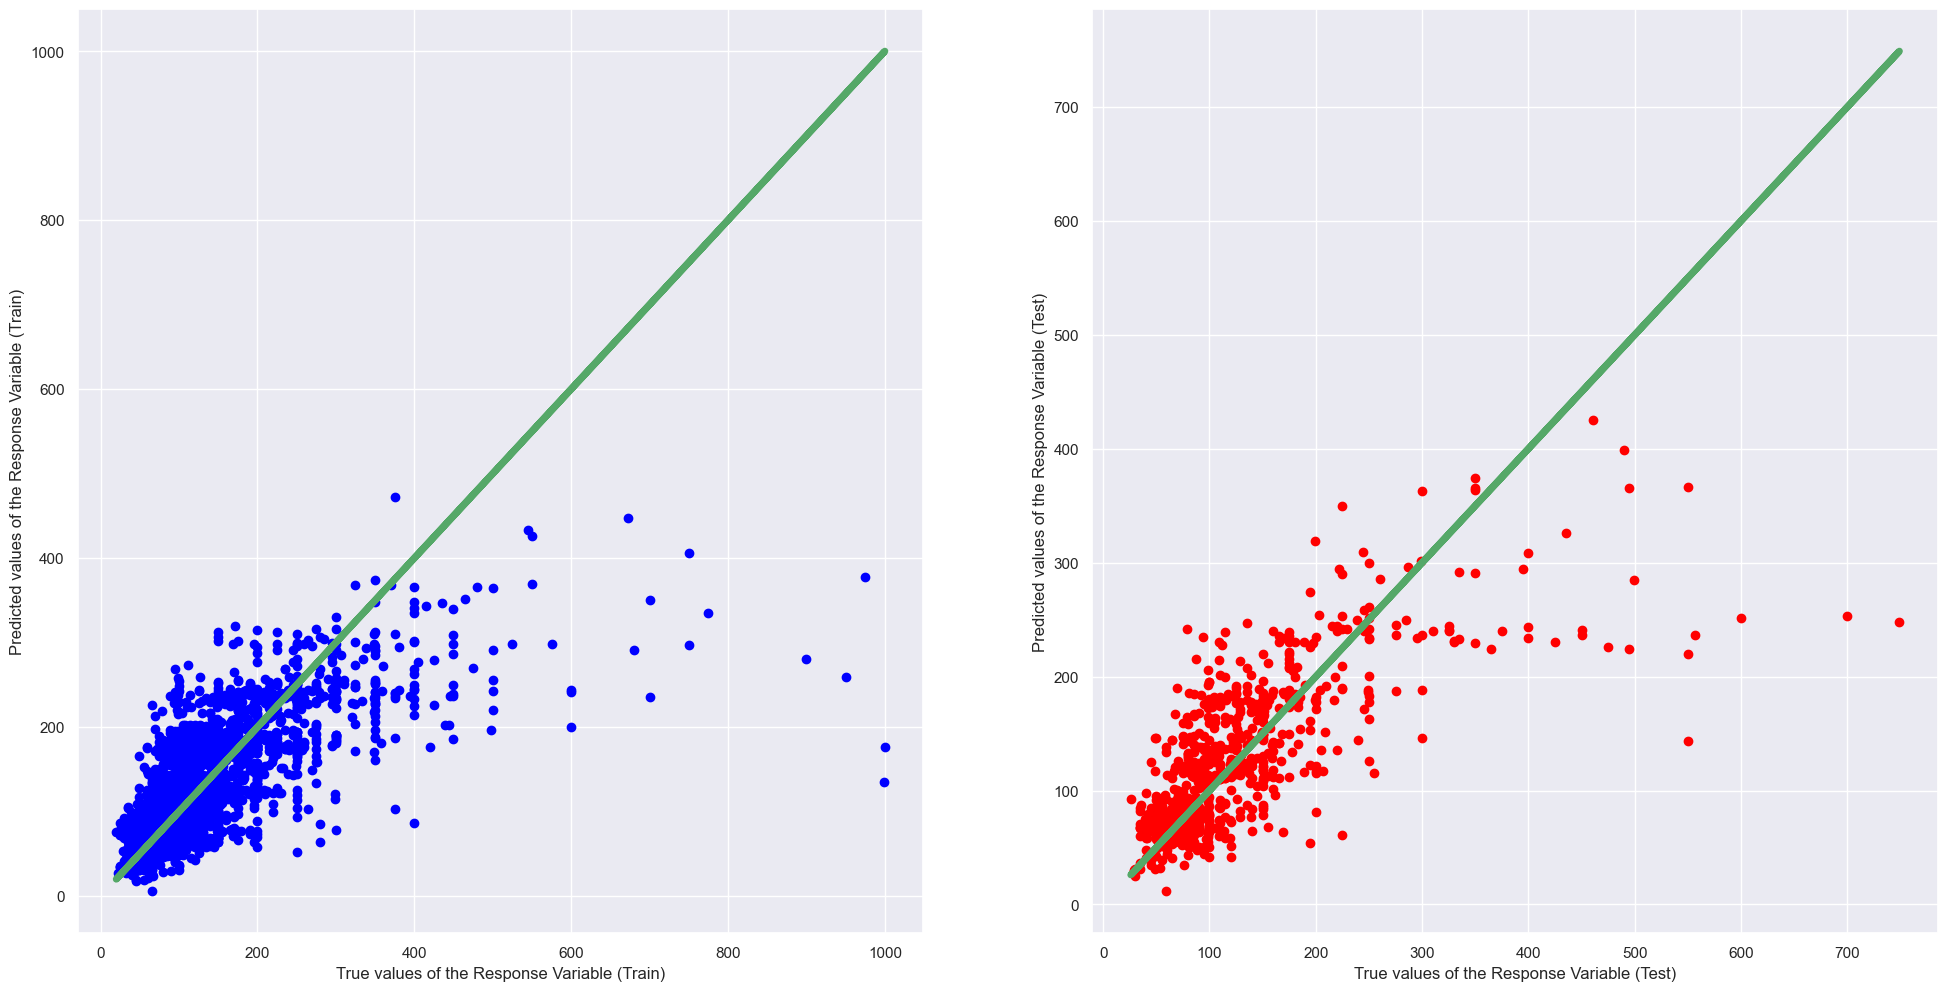

In [20]:
#plot the Predictions vs the True values
f, axes = plt.subplots(1, 2, figsize=(24, 12))
axes[0].scatter(y_train, trainPredictionLR, color = "blue")
axes[0].plot(y_train, y_train, 'g-', linewidth = 5)
axes[0].set_xlabel("True values of the Response Variable (Train)")
axes[0].set_ylabel("Predicted values of the Response Variable (Train)")
axes[1].scatter(y_test, testPredictionLR, color = "red")
axes[1].plot(y_test, y_test, 'g-', linewidth = 5)
axes[1].set_xlabel("True values of the Response Variable (Test)")
axes[1].set_ylabel("Predicted values of the Response Variable (Test)")

**Note that**: Points that lie on or near the diagonal line means that the values predicted by the Linear Regression model are highly accurate. If the points are away from the diagonal line, the points have been wrongly predicted. 

### Model 2: Ridge Regression


Ridge Regression is meant to be an upgrade to linear regression. It is similar to linear regression where it can be used to for regression and classification.

Ridge Regression is good at handling overfitting.

The difference in the equation for Ridge Regression is that it penalize RSS by adding another term and search for the minimization.

We can iterate different $\lambda$ values as the additional term to find the best fit for a Ridge Regression model.

Ridge Regression does not drop any predictors unlike Lasso Regression, which is we will observe later on that the beta estimate will only converge to zero, but never reach zero.



In [21]:
from sklearn.linear_model import RidgeCV, LassoCV

#features shown in the Ridge and Lasso trace plots
trace_features = ['bedrooms', 'room_type_Entire_home_apt', 'elevator', 'gym', 'hot_tub_sauna_or_pool', 'child_friendly']

In [22]:
#fitting a Ridge model for each lambda value to see how the coefficients shrink
lambdas = np.arange(1, 2001, 1) #lambda value of 1 to 2000, in intervals of 1

ridgeCoefs = []
for alpha in lambdas:
    ridgeCoefs.append(Ridge(alpha=alpha).fit(X_train, y_train).coef_.ravel())
ridgeDF = pd.DataFrame(ridgeCoefs, index=lambdas, columns=X_train.columns)

#choosing the best lambda with 5-fold cross validation on the training set
#(choosing it by the training R^2 would always pick the smallest lambda, since regularization can only lower the training fit)
ridgeCV = RidgeCV(alphas=lambdas, cv=5).fit(X_train, y_train.values.ravel())
print("Best lambda (5-fold CV on training set):", ridgeCV.alpha_)

#fitting the final Ridge model with the best lambda
ridgeReg = Ridge(alpha=ridgeCV.alpha_).fit(X_train, y_train)
trainPredictionRidge = ridgeReg.predict(X_train)
testPredictionRidge = ridgeReg.predict(X_test)

Best lambda (5-fold CV on training set): 68


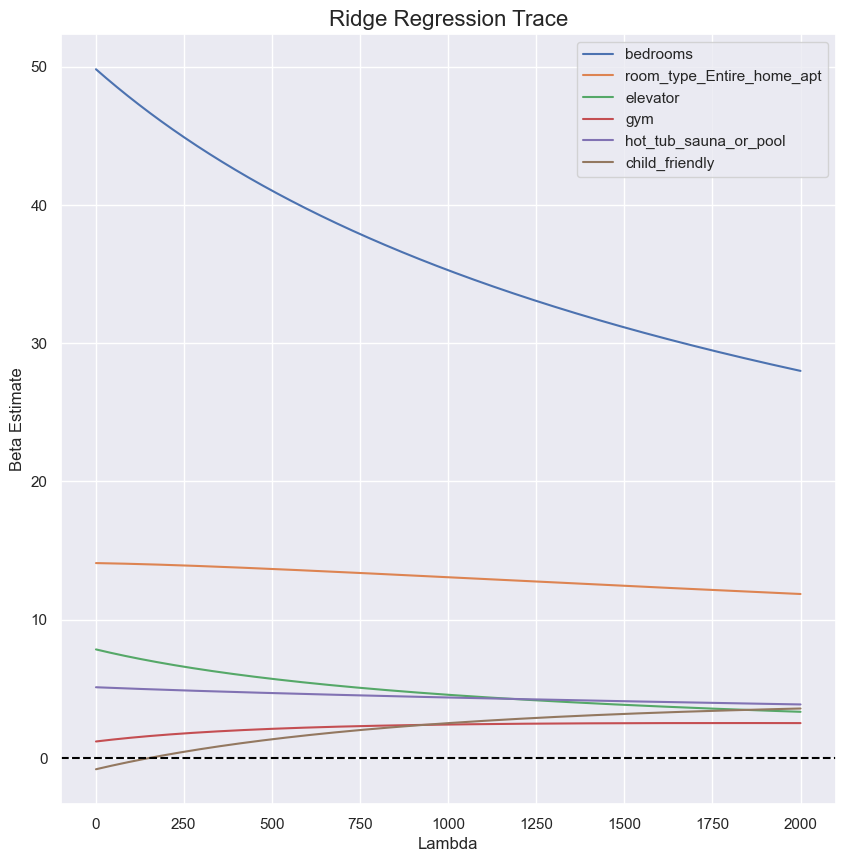

In [23]:
#plotting the Ridge Regression Trace
ax = ridgeDF[trace_features].plot(figsize=(10, 10))
ax.axhline(y=0, color='black', linestyle='--')
ax.set_xlabel("Lambda")
ax.set_ylabel("Beta Estimate")
ax.set_title("Ridge Regression Trace", fontsize=16)
ax.grid(True)

The trace shows how the Ridge coefficients of a few predictors shrink as lambda increases. **`bedrooms` has by far the largest coefficient** (about 50 at lambda = 1, still 28 at lambda = 2000), followed by `room_type_Entire_home_apt`. For Ridge Regression the coefficients shrink towards zero but never reach it, because Ridge does not drop any predictors, unlike Lasso Regression, which we will observe later on.

Lambda was chosen with 5-fold cross validation on the training set (best lambda = 68). The penalty only slightly changes the coefficients, so the Ridge model performs almost the same as Linear Regression.

Text(0, 0.5, 'Predicted values of the Response Variable (Test)')

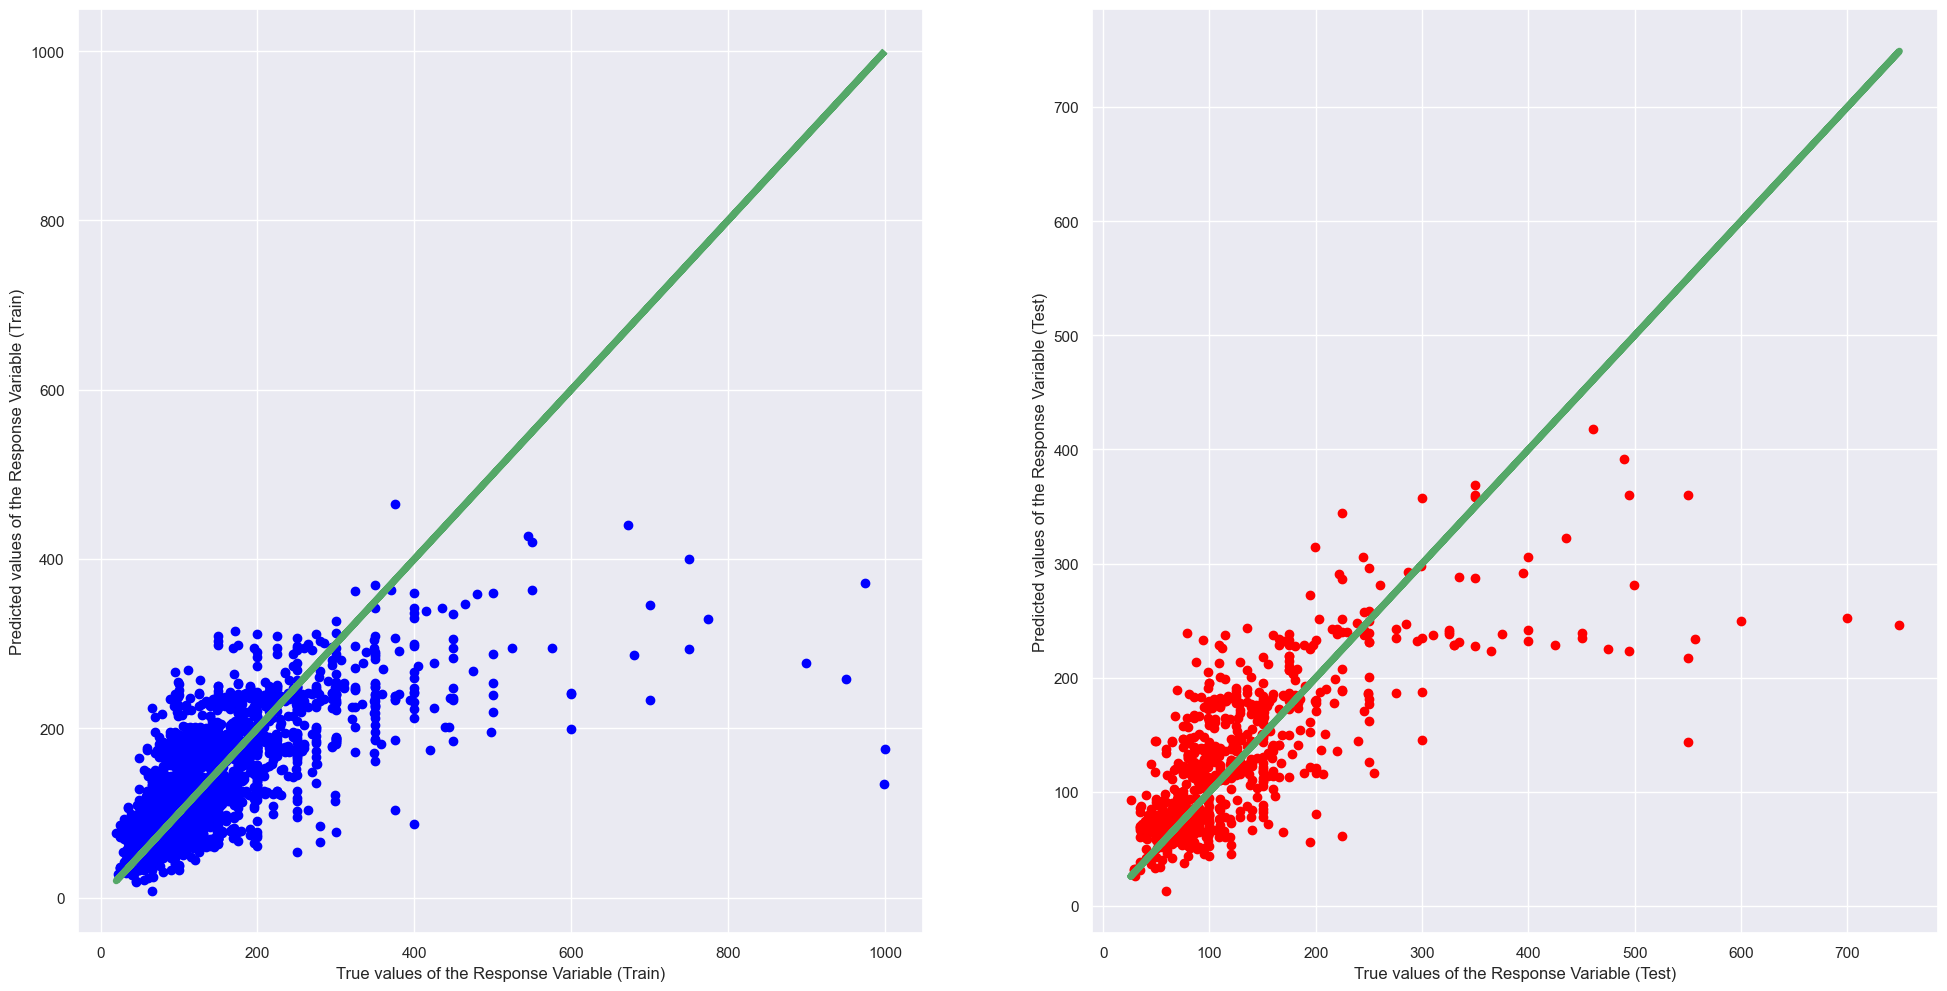

In [24]:
#plot the Predictions vs the True values
f, axes = plt.subplots(1, 2, figsize=(24, 12))
axes[0].scatter(y_train, trainPredictionRidge, color = "blue")
axes[0].plot(y_train, y_train, 'g-', linewidth = 5)
axes[0].set_xlabel("True values of the Response Variable (Train)")
axes[0].set_ylabel("Predicted values of the Response Variable (Train)")
axes[1].scatter(y_test, testPredictionRidge, color = "red")
axes[1].plot(y_test, y_test, 'g-', linewidth = 5)
axes[1].set_xlabel("True values of the Response Variable (Test)")
axes[1].set_ylabel("Predicted values of the Response Variable (Test)")

**Note that**: Points that lie on or near the diagonal line means that the values predicted by the Ridge Regression model are highly accurate. If the points are away from the diagonal line, the points have been wrongly predicted. 

### Model 3: Lasso Regression

Lasso Regression is similar to Ridge Regression, meant to be an upgrade to linear regression, it also can be used for Regression and Classification.

Lasso Regression can be used for feature selection, where some predictors will be dropped after a lambda reaches a certain value.

Lasson Regression also requires a $\lambda$ value to be iterated to find the best fit.


In [25]:
#fitting a Lasso model for each lambda value to see how the coefficients shrink to zero
lassoLambdas = np.arange(0.01, 8.01, 0.02) #lambda value of 0.01 to 8.01, in intervals of 0.02

lassoCoefs = []
for alpha in lassoLambdas:
    lassoCoefs.append(Lasso(alpha=alpha).fit(X_train, y_train).coef_.ravel())
lassoDF = pd.DataFrame(lassoCoefs, index=lassoLambdas, columns=X_train.columns)

#choosing the best lambda with 5-fold cross validation on the training set
lassoCV = LassoCV(alphas=lassoLambdas, cv=5).fit(X_train, y_train.values.ravel())
print("Best lambda (5-fold CV on training set):", round(lassoCV.alpha_, 2))

#fitting the final Lasso model with the best lambda
lassoReg = Lasso(alpha=lassoCV.alpha_).fit(X_train, y_train)
trainPredictionLasso = lassoReg.predict(X_train)
testPredictionLasso = lassoReg.predict(X_test)

#predictors dropped by the final Lasso model (coefficient exactly 0)
print("Predictors dropped by Lasso:", list(X_train.columns[lassoReg.coef_ == 0]))

Best lambda (5-fold CV on training set): 0.53
Predictors dropped by Lasso: ['white_goods', 'child_friendly', 'accessible', 'room_type_Private_room', 'property_type_Condominium', 'property_type_House']


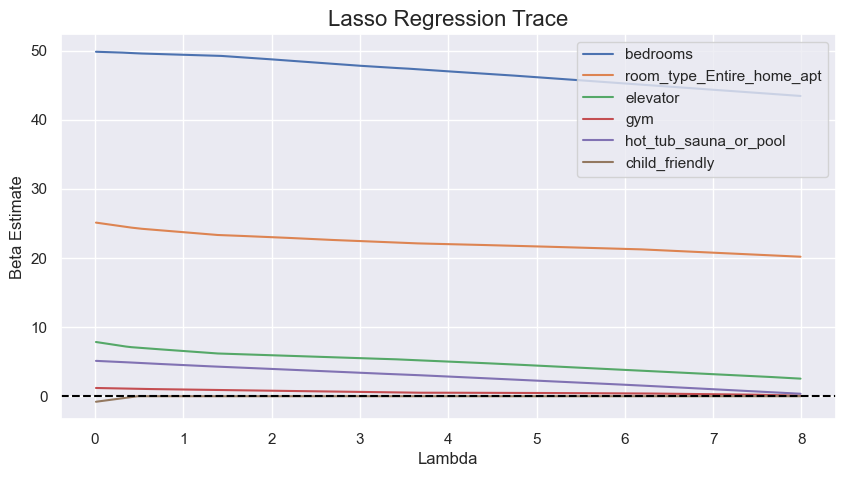

In [26]:
#Plot the Lasso Regression Trace
ax = lassoDF[trace_features].plot(figsize=(10, 5))
ax.axhline(y=0, color='black', linestyle='--')
ax.set_xlabel("Lambda")
ax.set_ylabel("Beta Estimate")
ax.set_title("Lasso Regression Trace", fontsize=16)
ax.grid(True)

The Lasso trace shows that **`bedrooms` and `room_type_Entire_home_apt` stay large even at the highest lambda of 8** (43 and 20), while the amenity coefficients shrink towards zero. `child_friendly` is dropped (coefficient exactly 0) from lambda of about 0.5, and `gym` and `hot_tub_sauna_or_pool` are close to zero by lambda = 8.

With the lambda chosen by 5-fold cross validation (0.53), Lasso drops 6 predictors: `white_goods`, `child_friendly`, `accessible`, `room_type_Private_room`, `property_type_Condominium` and `property_type_House`. Dropping them barely changes the performance, so they add little information beyond the other predictors.

Text(0, 0.5, 'Predicted values of the Response Variable (Test)')

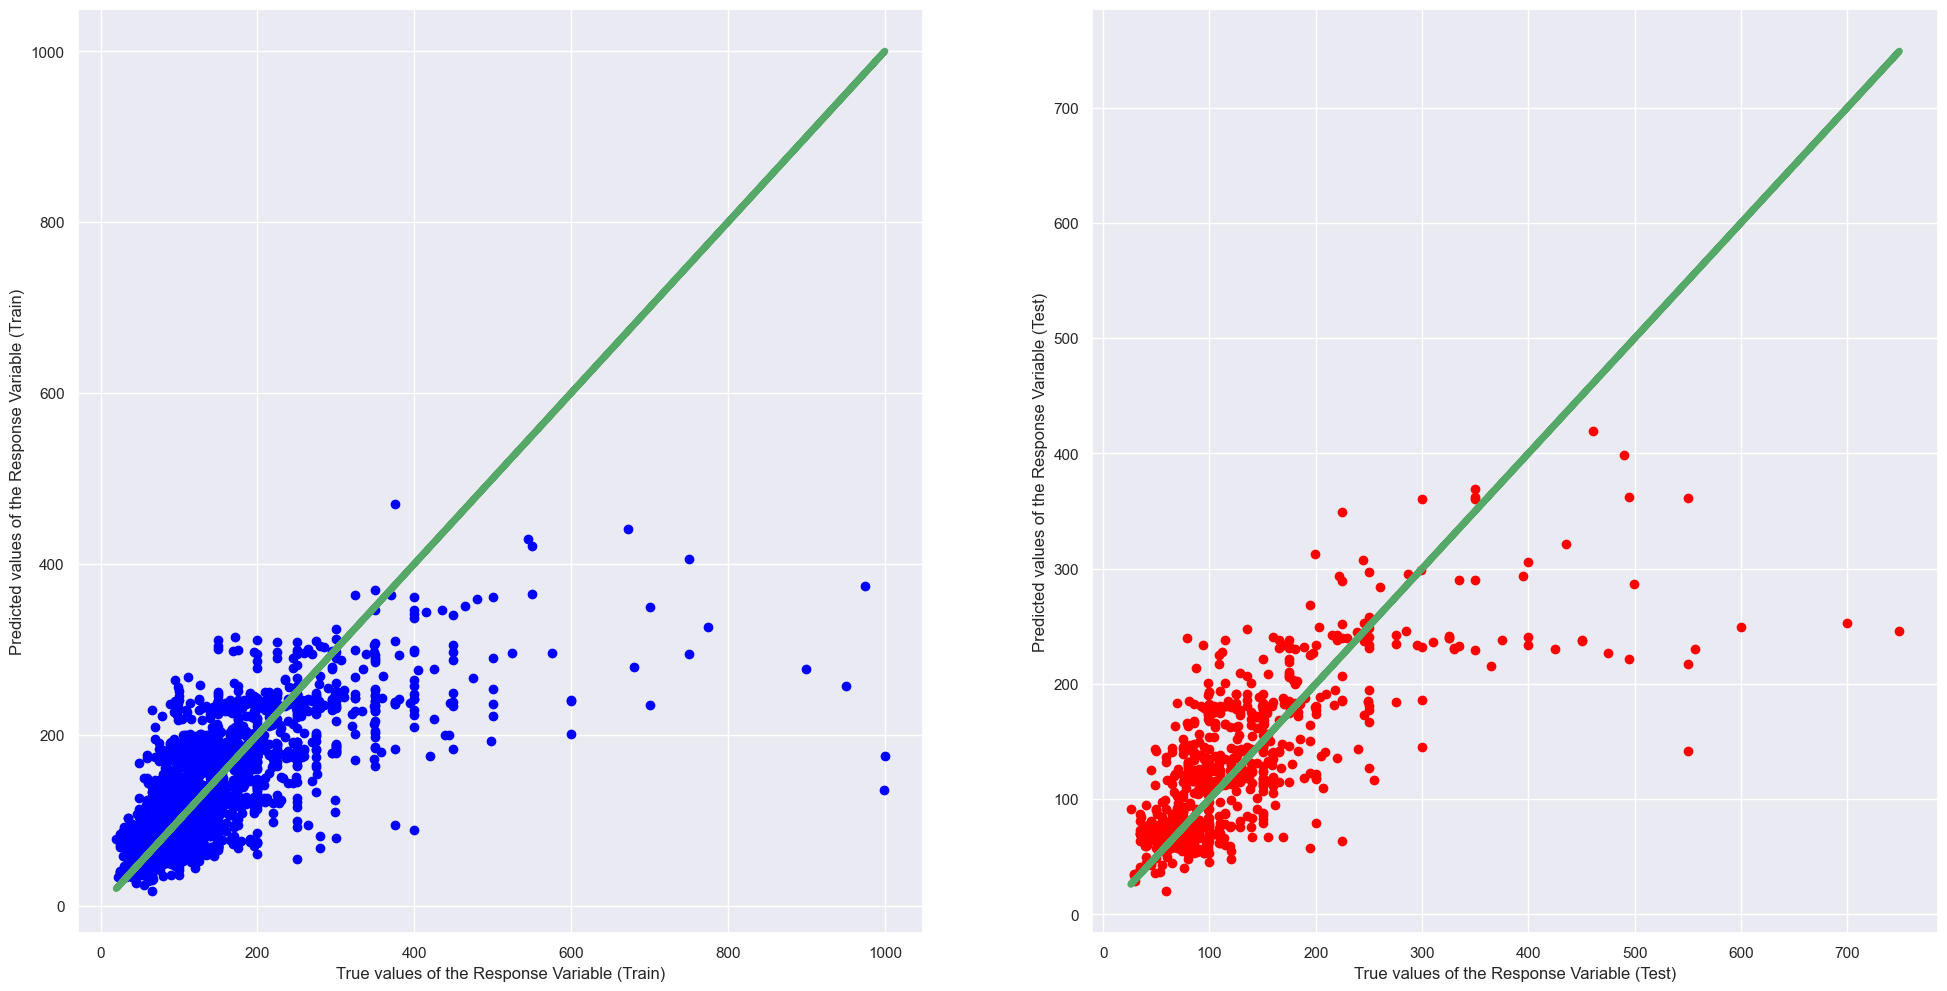

In [27]:
#plot the Predictions vs the True values
f, axes = plt.subplots(1, 2, figsize=(24, 12))
axes[0].scatter(y_train, trainPredictionLasso, color = "blue")
axes[0].plot(y_train, y_train, 'g-', linewidth = 5)
axes[0].set_xlabel("True values of the Response Variable (Train)")
axes[0].set_ylabel("Predicted values of the Response Variable (Train)")
axes[1].scatter(y_test, testPredictionLasso, color = "red")
axes[1].plot(y_test, y_test, 'g-', linewidth = 5)
axes[1].set_xlabel("True values of the Response Variable (Test)")
axes[1].set_ylabel("Predicted values of the Response Variable (Test)")

**Note that**: Points that lie on or near the diagonal line means that the values predicted by the Lasso Regression model are highly accurate. If the points are away from the diagonal line, the points have been wrongly predicted. 

### Model 4: Random Forest Regression

Random Forest is an emsemble technique that is able to perform both Regression and Classification tasks with the use of multiple decision trees and a technique that is called Bootstrap Aggression. The idea behind this technique is to combine multiple decision trees in its prediction rather than replying on individual decision trees. 

Here, we use the RandomForestRegressor to help predict the price.

In [28]:
# Tuning of Parameters

# random_grid = {'n_estimators': [2000],
#                'max_features': [2,5],
#                'max_depth': [40,70],
#                'min_samples_split': [40,50],
#                'max_leaf_nodes':[50,70],
#                'max_features': [2,5]}
# rf_tune = RandomForestRegressor()
# rf_random = GridSearchCV(estimator = rf_tune, param_grid = random_grid, cv = 3, verbose=2,n_jobs = 2)

# rf_random.fit(X_train,y_train)

# print(rf_random.best_estimator_)

The parameters of the Random Forest model were chosen from the grid above with `GridSearchCV`. The search is commented out because it takes a long time to run. The final model below uses `n_estimators=2000, max_depth=40, min_samples_split=50, max_leaf_nodes=70, max_features=5`, and `random_state=42` so that the results are reproducible.

In [29]:
#creating and fitting the model (random_state makes the results reproducible)
RF = RandomForestRegressor(n_estimators=2000, max_depth=40, min_samples_split=50,
                           max_leaf_nodes=70, max_features=5, random_state=42, n_jobs=-1).fit(X_train, y_train.values.ravel())

# predicting the training and testing sets
trainPredictin_RF = RF.predict(X_train)
testPredictin_RF = RF.predict(X_test)

In [30]:
importancesRF = RF.feature_importances_
feat_imp1 = pd.DataFrame(importancesRF, columns=['Weight'], index=X_train.columns)
feat_imp1.sort_values('Weight', inplace=True)
feat_imp1

,Weight
property_type_Bed_and_Breakfast,0.001360
smoking_allowed,0.001421
property_type_Condominium,0.001549
property_type_Loft,0.002600
accessible,0.002693
property_type_Townhouse,0.003089
internet,0.003847
breakfast,0.003938
check_in_24h,0.004305
parking,0.004532


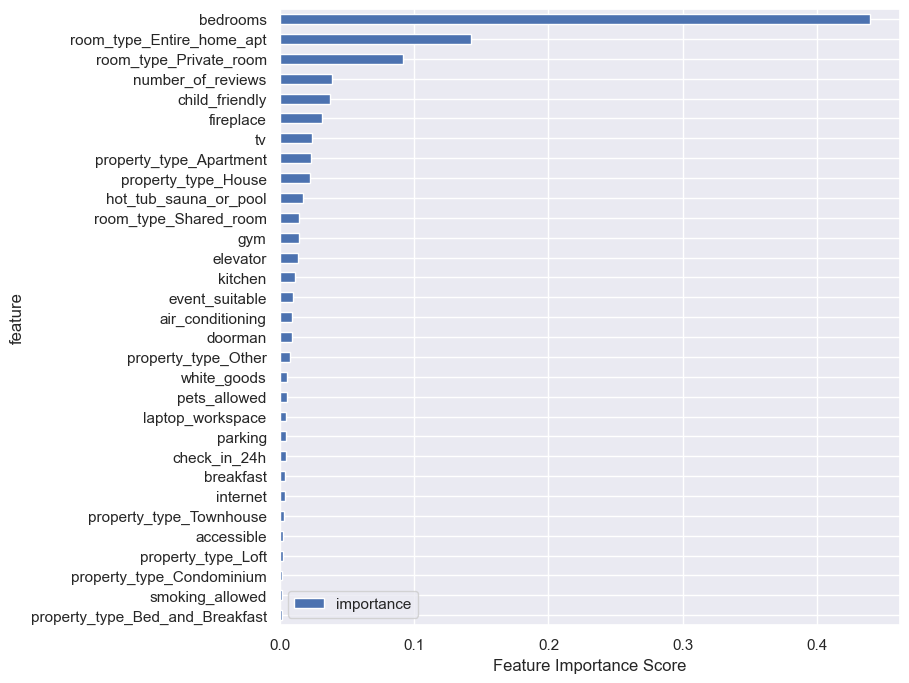

In [31]:
feat_imp = pd.DataFrame({'importance':RF.feature_importances_})  
feat_imp['feature'] = X_train.columns
feat_imp.sort_values(by='importance', ascending=False, inplace=True)

feat_imp.sort_values(by='importance', inplace=True)
feat_imp = feat_imp.set_index('feature', drop=True)
feat_imp.plot.barh(figsize=(8,8))
plt.xlabel('Feature Importance Score')
plt.show()

Importance provides a score that indicates how useful or valuable each feature was in the construction of the decision trees within the model. The more a variable is used to make key decisions with decision trees, the higher its relative importance.

As such, feature importance can be used to interpret our data to understand the most important features that define our predictions. In this case, looking at the bar chart above, the predictor variable that is associated with a taller bar means that the variable has a higher importance in the Random Tree Regression Model in predicting price. 

Text(0, 0.5, 'Predicted values of the Response Variable (Test)')

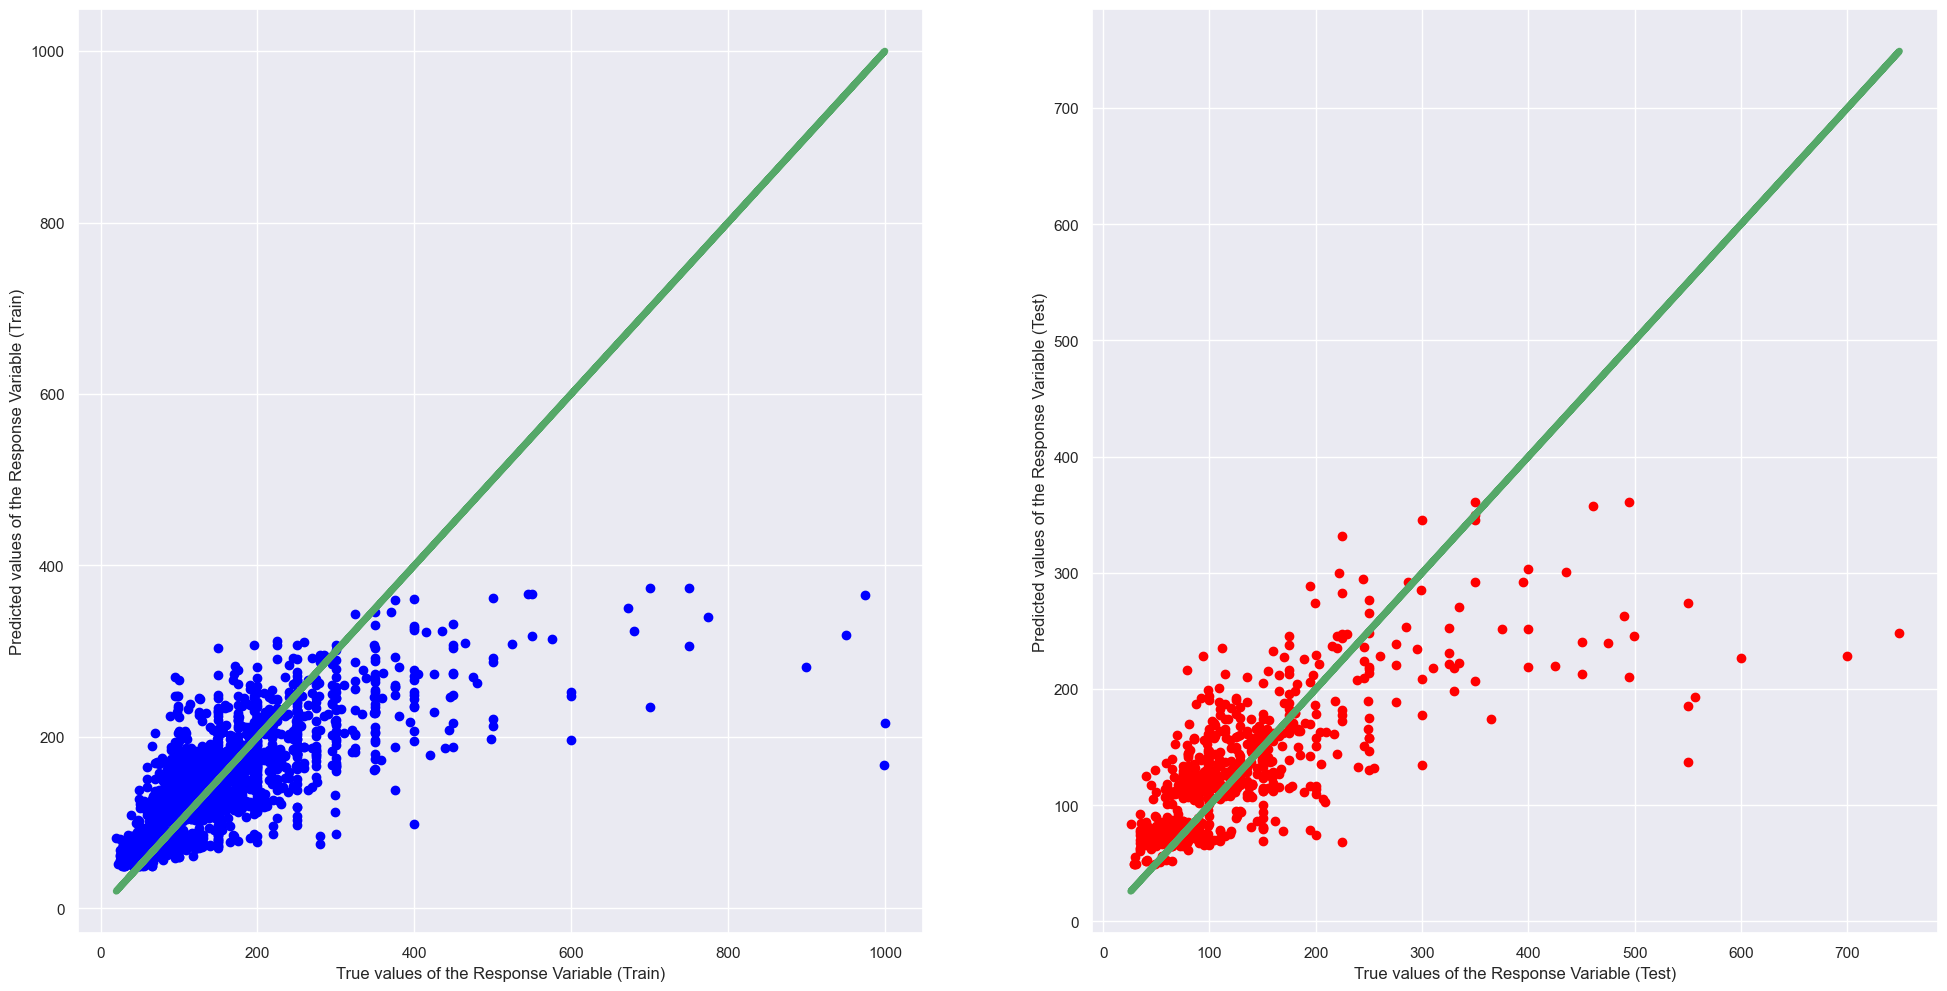

In [32]:
#plot the Predictions vs the True values
f, axes = plt.subplots(1, 2, figsize=(24, 12))
axes[0].scatter(y_train, trainPredictin_RF, color = "blue")
axes[0].plot(y_train, y_train, 'g-', linewidth = 5)
axes[0].set_xlabel("True values of the Response Variable (Train)")
axes[0].set_ylabel("Predicted values of the Response Variable (Train)")
axes[1].scatter(y_test, testPredictin_RF, color = "red")
axes[1].plot(y_test, y_test, 'g-', linewidth = 5)
axes[1].set_xlabel("True values of the Response Variable (Test)")
axes[1].set_ylabel("Predicted values of the Response Variable (Test)")

**Note that**: Points that lie on or near the diagonal line means that the values predicted by the Random Forest Regression model are highly accurate. If the points are away from the diagonal line, the points have been wrongly predicted. 

### Model 5 : XGBoost

XGBoost is an open source library that provides a high-performance implementation of gradient boost decision trees (similar to the decision trees that we have learnt). It is a machine learning model that is able to perform prediction tasks regardless of Regression or Classification. 

The key idea of Gradient Boosted Decision Trees is that they build a series of trees in which each tree is trained so that it attempts to correct the mistakes of the previous tree in the seroes.

In [33]:
#Tuning the Parameters

# parameters_for_testing = {
#     'colsample_bytree':[0.3,0.5],
#     'learning_rate':[0.1,0.5],
#     'alpha': [10,12],
#     'max_depth':[3,5],
#     'n_estimators':[2000],  
# }

                    
# xgb_model = xgb.XGBRegressor(learning_rate =0.1, n_estimators=1000, max_depth=5,
#      gamma=0, colsample_bytree=0.8)

# gsearch1 = GridSearchCV(estimator = xgb_model, param_grid = parameters_for_testing, n_jobs=6,iid=False, verbose=10,scoring='neg_mean_squared_error')
# gsearch1.fit(X_train,y_train)

# print(gsearch1.best_estimator_)

To optimize the parameters used in the XGBoost modelling algorithm, GridSearchCV was run over the grid above. The search is commented out because it takes a long time to run. The chosen parameters are `colsample_bytree=0.3, learning_rate=0.1, max_depth=3, alpha=10, n_estimators=2000`, which are used in the model below (with the objective `reg:squarederror`, the current name of the old `reg:linear`, and `random_state=42` for reproducibility).

In [34]:
#fitting and Training the model for Train & Test sets
#('reg:squarederror' is the current name of the old 'reg:linear' objective)
xgb_reg = xgb.XGBRegressor(objective='reg:squarederror', colsample_bytree=0.3, learning_rate=0.1,
                           max_depth=3, alpha=10, n_estimators=2000, random_state=42)

xgb_reg.fit(X_train, y_train)

#predicting using the model
trainPredictin_xgb_reg = xgb_reg.predict(X_train)
testPredictin_xgb_reg = xgb_reg.predict(X_test)

In [35]:
import shutil

# Graphviz's `dot` program must be installed and on PATH to render the tree below
# (macOS: `brew install graphviz`, Ubuntu: `apt install graphviz`, Windows: https://graphviz.org/download/)
print("dot found at:", shutil.which("dot"))

dot found at: /opt/homebrew/bin/dot


/Users/rutikakadam/Documents/My Studies/Projects/Airbnb_Seattle/.venv/lib/python3.12/site-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


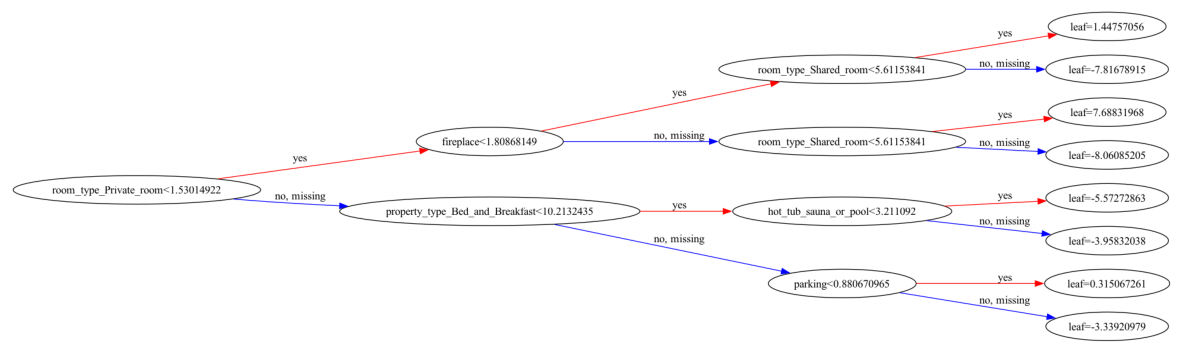

In [36]:
#ploting decision tree 
xgb.plot_tree(xgb_reg, num_trees=0, rankdir='LR')
fig = plt.gcf()
fig.set_size_inches(15, 20)

In [37]:
# Weightage/Importance of each variable 
ft_weights_xgb_reg = pd.DataFrame(xgb_reg.feature_importances_, columns=['weight'], index=X_train.columns)
ft_weights_xgb_reg.sort_values('weight', inplace=True)
ft_weights_xgb_reg

,weight
smoking_allowed,0.004044
accessible,0.005729
breakfast,0.006046
property_type_Townhouse,0.006104
property_type_Loft,0.007116
white_goods,0.007665
property_type_Condominium,0.008733
internet,0.009162
event_suitable,0.009582
property_type_Bed_and_Breakfast,0.010389


Importance provides a score that indicates how useful or valuable each feature was in the construction of the boosted decision trees within the model. The more a variable is used to make key decisions with decision trees, the higher its relative importance.

As such, feature importance can be used to interpret our data to understand the most important features that define our predictions. In this case, looking at the table above, the predictor variable that is associated with a higher number means that the variable has a higher importance in the XGBoost Regression Model in predicting price. 

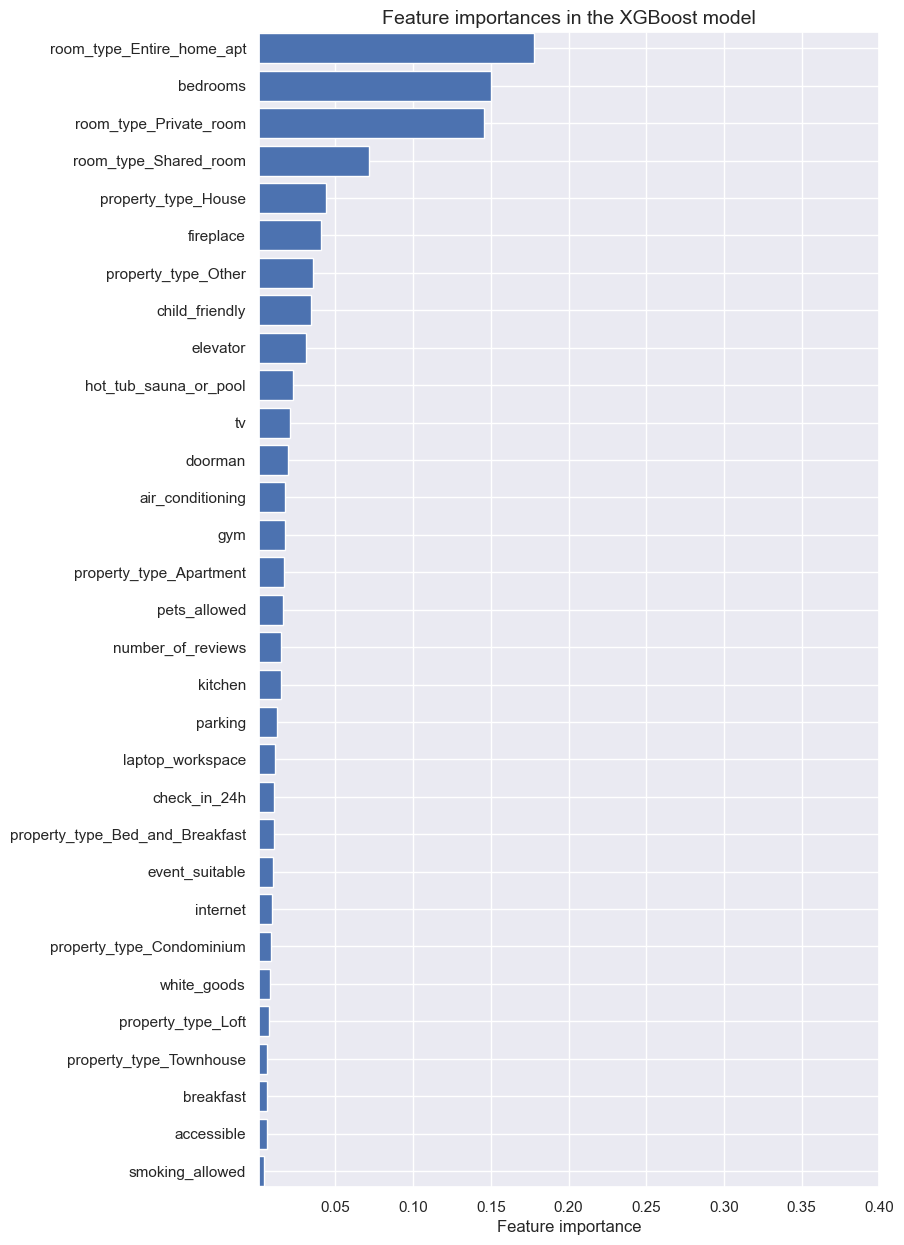

In [38]:
#plotting feature importances
plt.figure(figsize=(8,15))
plt.barh(ft_weights_xgb_reg.index, ft_weights_xgb_reg.weight, align='center') 
plt.title("Feature importances in the XGBoost model", fontsize=14)
plt.xlabel("Feature importance")
plt.margins(y=0.001)
plt.xlim(0.001, 0.4)
plt.show()

Text(0, 0.5, 'Predicted values of the Response Variable (Test)')

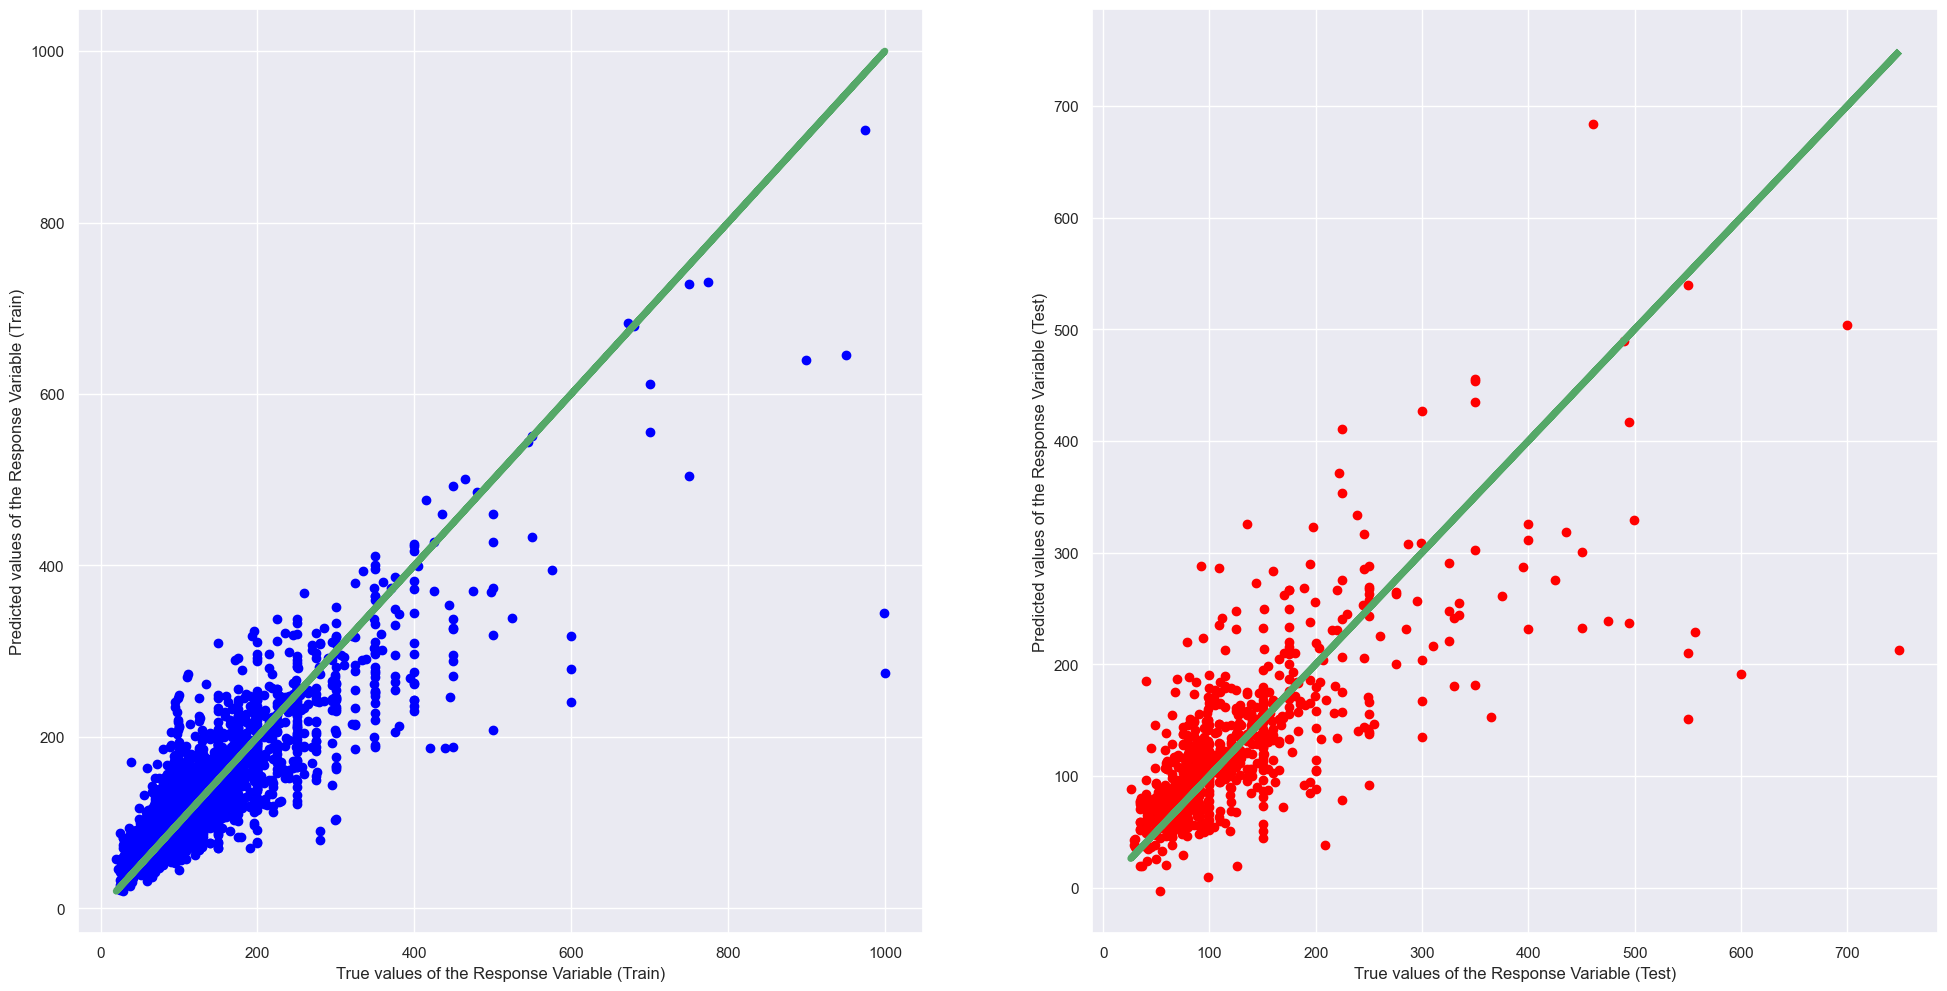

In [39]:
#plot the Predictions vs the True values
f, axes = plt.subplots(1, 2, figsize=(24, 12))
axes[0].scatter(y_train, trainPredictin_xgb_reg, color = "blue")
axes[0].plot(y_train, y_train, 'g-', linewidth = 5)
axes[0].set_xlabel("True values of the Response Variable (Train)")
axes[0].set_ylabel("Predicted values of the Response Variable (Train)")
axes[1].scatter(y_test, testPredictin_xgb_reg, color = "red")
axes[1].plot(y_test, y_test, 'g-', linewidth = 5)
axes[1].set_xlabel("True values of the Response Variable (Test)")
axes[1].set_ylabel("Predicted values of the Response Variable (Test)")

**Note that**: Points that lie on or near the diagonal line means that the values predicted by the XGBoost Regression model are highly accurate. If the points are away from the diagonal line, the points have been wrongly predicted.

### Model 6: CatBoost 

CatBoost is a high performance open source gradient boosting on decision trees. It can be used to solve both Classification and Regression problems. 

In [40]:
# catBoost = CatBoostRegressor()
# parameters = {'depth'         : [3,5],
#                 'learning_rate' : [0.1,0.5],
#                 'iterations'    : [2000]
#                 }
# grid = GridSearchCV(estimator=catBoost, param_grid = parameters, cv = 2, n_jobs=6)
# grid.fit(X_train, y_train)

# print("\n The best parameters across ALL searched params:\n",
#           grid.best_params_)

To optimize the parameters used in the CatBoost modelling algorithm, we first tune the parameters - in which GridSearchCV was used to optimize the parameters to determine the values that impact the model in order to enable the algorithm to perform at its best. In this case, while we managed to get the optimal parameter values (for at least the more significant parameters), we commented off the code as it would take a decent amount of time to process. The output of the code is as follows:

{'depth': 3, 'iterations': 2000, 'learning_rate': 0.1}

In [41]:
#Creating and fitting the model (verbose=0 hides the training log of 2000 iterations)
CatB = CatBoostRegressor(iterations=2000, depth=3, learning_rate=0.1, loss_function='RMSE',
                         random_seed=42, verbose=0)
CatB.fit(X_train, y_train)

#Predicting based on the model
trainPrediction_CatB = CatB.predict(X_train)
testPrediction_CatB = CatB.predict(X_test)

(0.001, 20.0)

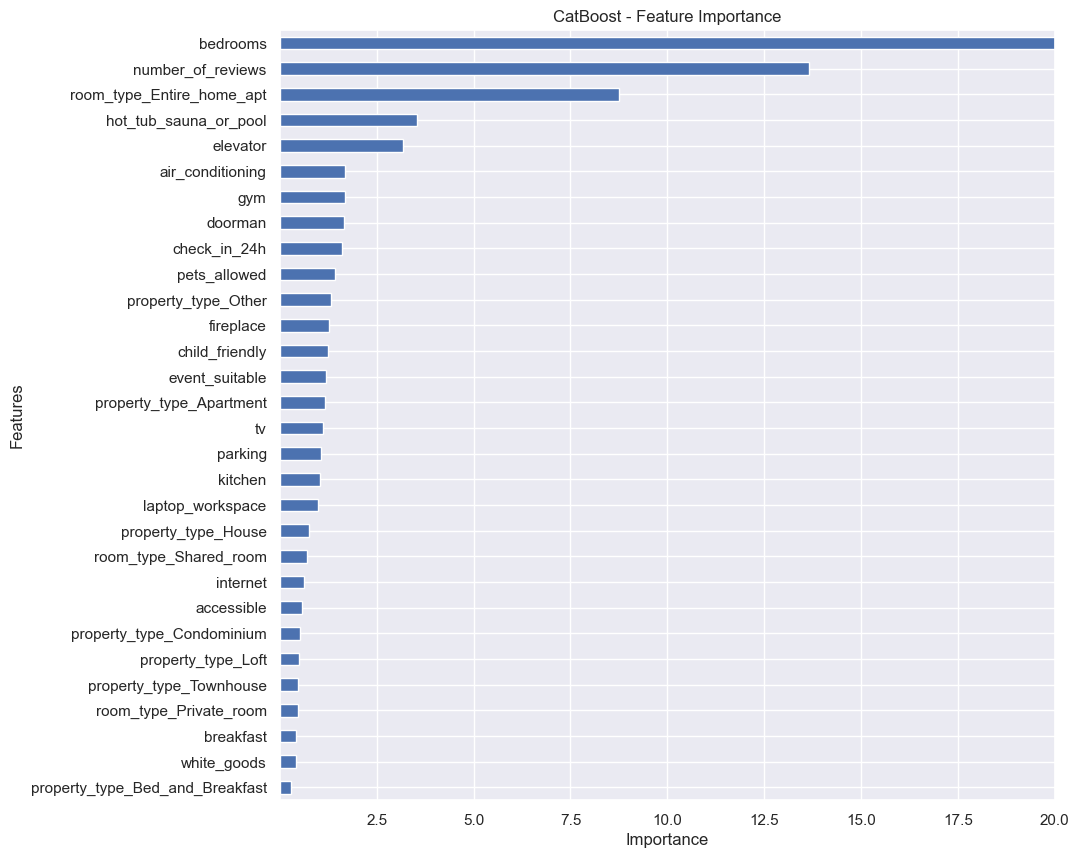

In [42]:
#plotting the feature importance diagram
feature_impCatB = pd.DataFrame({'imp': CatB.feature_importances_, 'col': X.columns})
feature_impCatB = feature_impCatB.sort_values(['imp', 'col'], ascending=[True, False]).iloc[-30:]
feature_impCatB.plot(kind='barh', x='col', y='imp', figsize=(10, 10), legend=None)
plt.title('CatBoost - Feature Importance')
plt.ylabel('Features')
plt.xlabel('Importance');
plt.xlim(0.001, 20.0)

Importance provides a score that indicates how useful or valuable each feature was in the construction of the boosted decision trees within the model. The more a variable is used to make key decisions with decision trees, the higher its relative importance.

As such, feature importance can be used to interpret our data to understand the most important features that define our predictions. In this case, looking at the bar chart above, the predictor variable that is associated with a longer bar means that the variable has a higher importance in the CatBoost Regression Model in predicting price. 

Text(0, 0.5, 'Predicted values of the Response Variable (Test)')

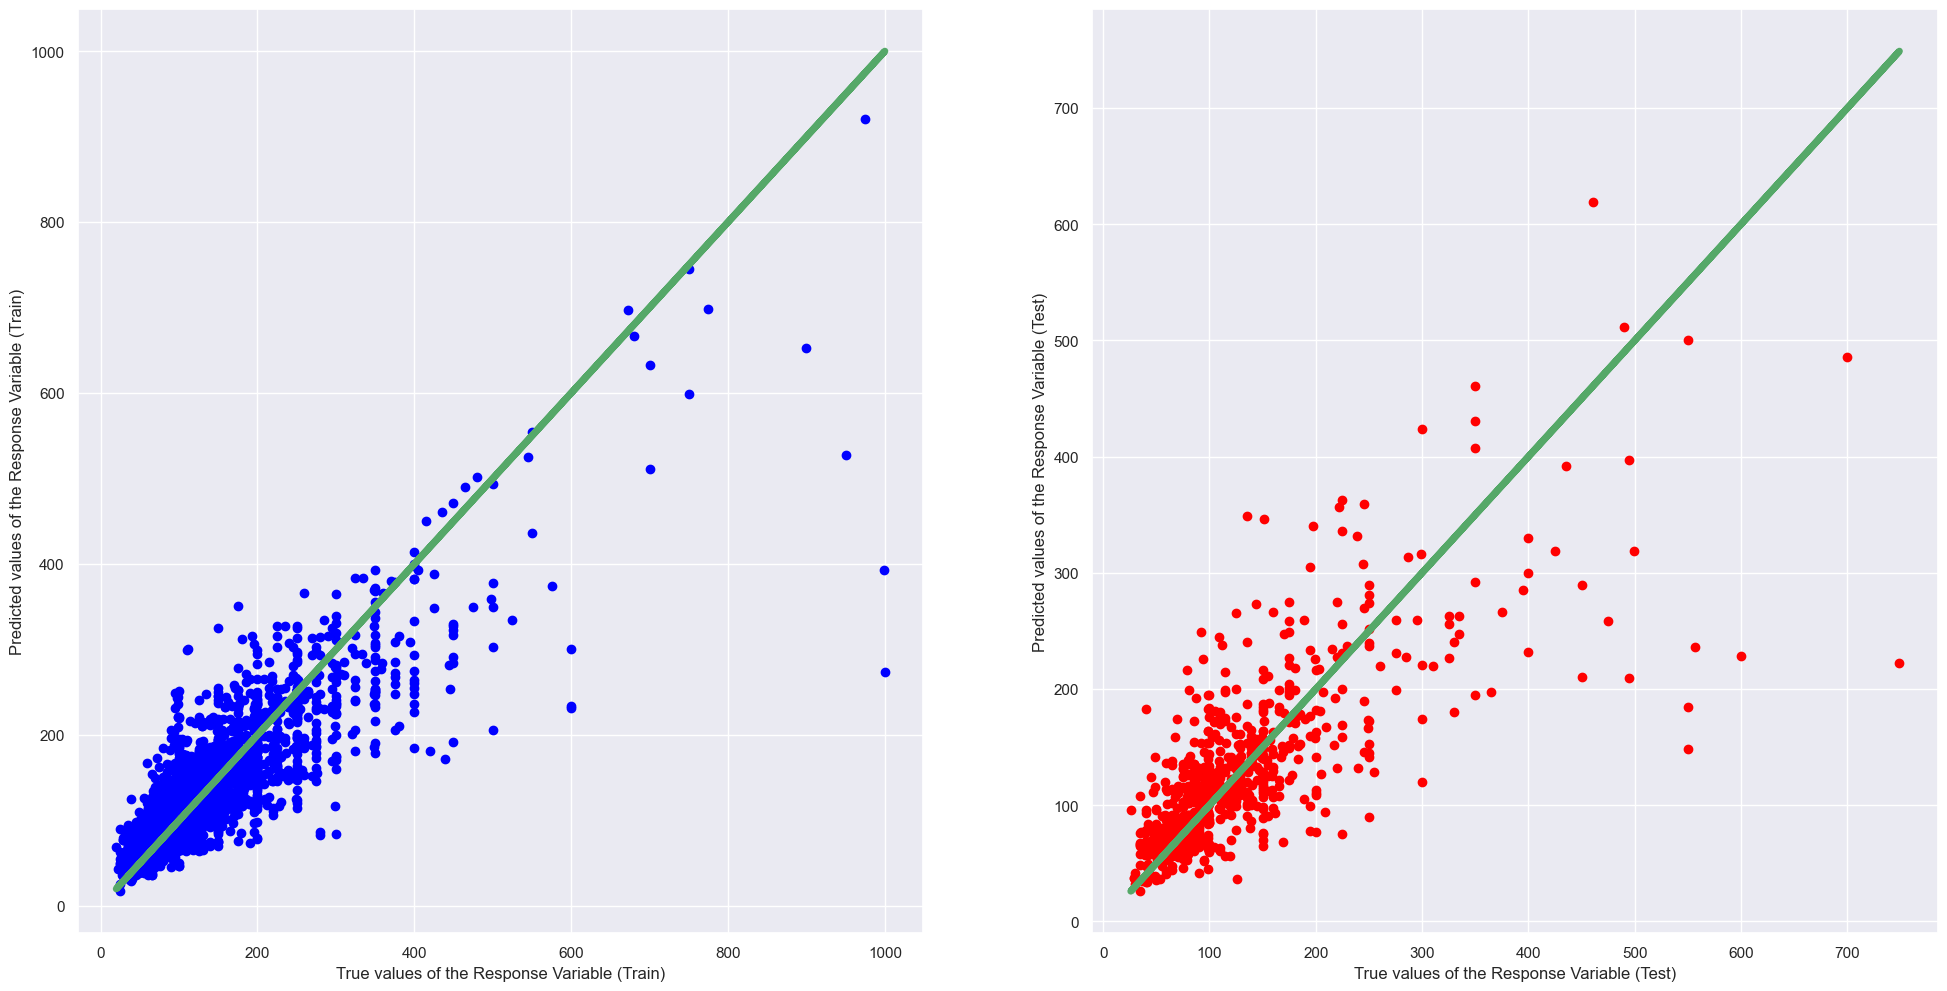

In [43]:
#plot the Predictions vs the True values
f, axes = plt.subplots(1, 2, figsize=(24, 12))
axes[0].scatter(y_train, trainPrediction_CatB, color = "blue")
axes[0].plot(y_train, y_train, 'g-', linewidth = 5)
axes[0].set_xlabel("True values of the Response Variable (Train)")
axes[0].set_ylabel("Predicted values of the Response Variable (Train)")
axes[1].scatter(y_test, testPrediction_CatB, color = "red")
axes[1].plot(y_test, y_test, 'g-', linewidth = 5)
axes[1].set_xlabel("True values of the Response Variable (Test)")
axes[1].set_ylabel("Predicted values of the Response Variable (Test)")

**Note that**: Points that lie on or near the diagonal line means that the values predicted by the CatBoost Regression model are highly accurate. If the points are away from the diagonal line, the points have been wrongly predicted.

### Evaluation of Models

#### Train Test Split
Validation of model performance is done using Train/Test Set Split in which the data set is split into 80% : 20%. 

In [44]:
# Results of Model on the 80/20 train/test split
test_predictions = {
    'Linear Regression': (trainPredictionLR, testPredictionLR),
    'Ridge Regression':  (trainPredictionRidge, testPredictionRidge),
    'Lasso Regression':  (trainPredictionLasso, testPredictionLasso),
    'Random Forest':     (trainPredictin_RF, testPredictin_RF),
    'XGBoost':           (trainPredictin_xgb_reg, testPredictin_xgb_reg),
    'CatBoost':          (trainPrediction_CatB, testPrediction_CatB),
}

splitResultsDF = pd.DataFrame({
    'Train R^2': [r2_score(y_train, train) for train, test in test_predictions.values()],
    'Test R^2':  [r2_score(y_test, test) for train, test in test_predictions.values()],
    'Test MSE':  [mean_squared_error(y_test, test) for train, test in test_predictions.values()],
    'Test RMSE': [np.sqrt(mean_squared_error(y_test, test)) for train, test in test_predictions.values()],
}, index=list(test_predictions))

print("Goodness Fit on the Models (Train/Test Split):")
splitResultsDF.round(3)

Goodness Fit on the Models (Train/Test Split):


,Train R^2,Test R^2,Test MSE,Test RMSE
Linear Regression,0.513,0.543,3710.371,60.913
Ridge Regression,0.512,0.543,3710.544,60.914
Lasso Regression,0.512,0.544,3703.710,60.858
Random Forest,0.560,0.528,3834.456,61.923
XGBoost,0.749,0.531,3806.837,61.700
CatBoost,0.728,0.550,3653.494,60.444


However, Random Train/Test Set Splits may not always be enough as it can be subjected to selection biased during the split process (even if its randomly split). This is especially so if the dataset is small. Train/Test Set Splits can also cause over-fitted predicted models that can also affect its performance metrics. 

As such, to overcome the pitfalls in Train/Test set split evaluation, k-fold Cross Validation is also performed. Here, the whole dataset is used to calcualte the performance of the regression models. This validation method is more popular simply because it generally results in a less biased or less optimistic estimate of the model. 

#### K-fold Cross Validation

K-Fold Cross Validation is where the dataset will be split into k number of folds in which each fold is used as a testing point.

Here, k=10 is used as it is a value that has been found to generally result in a model skill estimate with low bias and a modest variance. 

In [45]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.base import clone

kf = KFold(n_splits=10, shuffle=True, random_state=100)

scoring = ['r2', 'neg_mean_squared_error']

#each model is wrapped in a pipeline with the scaler, so that in every fold the scaler is fitted on the training folds only
#clone() creates a fresh, unfitted copy of each model with the same parameters (e.g. the chosen Ridge and Lasso lambdas)
cv_models = {
    'Linear Regression': linreg,
    'Ridge Regression':  ridgeReg,
    'Lasso Regression':  lassoReg,
    'Random Forest':     RF,
    'XGBoost':           xgb_reg,
    'CatBoost':          CatB,
}

cv_results = {}
for name, model in cv_models.items():
    cv_results[name] = cross_validate(make_pipeline(StandardScaler(), clone(model)), X, y.values.ravel(), cv=kf, scoring=scoring)

In [46]:
cvResultsDF = pd.DataFrame({
    'CV R^2':  [cv_results[name]['test_r2'].mean() for name in cv_models],
    'CV MSE':  [-cv_results[name]['test_neg_mean_squared_error'].mean() for name in cv_models],
    'CV RMSE': [np.sqrt(-cv_results[name]['test_neg_mean_squared_error']).mean() for name in cv_models],
}, index=list(cv_models))

print("Goodness Fit on the Models (K-Fold Cross Validation):")
cvResultsDF.round(3)

Goodness Fit on the Models (K-Fold Cross Validation):


,CV R^2,CV MSE,CV RMSE
Linear Regression,0.508,3997.064,62.423
Ridge Regression,0.509,3996.838,62.400
Lasso Regression,0.509,3993.393,62.384
Random Forest,0.511,4039.995,62.458
XGBoost,0.510,3917.898,62.015
CatBoost,0.509,3936.479,62.172


**Observation**

Under 10-fold cross validation, **all six models perform almost the same**: R^2 between 0.508 and 0.511 and RMSE between about $62.0 and $62.5. The differences are much smaller than the variation between folds, so no model is clearly better than the others.

- Linear, Ridge and Lasso Regression give practically identical results, because the chosen regularization barely changes the coefficients.
- On the single 80/20 split, CatBoost has the best test score (R^2 0.550), but this does not hold up under cross validation, so it is most likely luck of the split.
- XGBoost and CatBoost fit the training data much better (R^2 0.75 and 0.73) than unseen data (about 0.51 in cross validation), which shows that they **overfit**. The more complex models do not improve on Linear Regression here.

### The Most Important Features of a Property Listing

Since all the models perform about the same, we use the Random Forest model to look at which features drive its predictions, because tree-based predictions can be decomposed feature by feature. Across the Random Forest and XGBoost feature importances and the Linear Regression coefficients, the most important predictors are consistently **`bedrooms` and room type** (entire home vs private/shared room).

We first test out its prediction on a specific instance. Then, using a library called TreeInterpreter, we decompose the Random Forest prediction into a sum of contributions from each feature:

>(Prediction = Bias + Feature1 x Contribution1 + … + FeatureN x ContributionN.)

This will show us how each individual feature contributed in its prediction based on individual results. A positive result would mean that the feature has a positive impact on the prediction while a negative result shows a negative impact.

If the prediction of price is fairly accurate (comparing to its true value), then its contributions of individual features would also be deemed fairly reliable.

In [47]:
# If not installed yet:
# !uv pip install treeinterpreter packaging  # or: pip install treeinterpreter packaging

import sys, types

# Provide a minimal compat layer for distutils.version.LooseVersion
try:
    import distutils.version  # will fail on Python 3.12+
except Exception:
    from packaging.version import Version
    m = types.ModuleType("distutils.version")
    class LooseVersion(Version):
        pass
    m.LooseVersion = LooseVersion
    sys.modules["distutils.version"] = m


In [48]:
from treeinterpreter import treeinterpreter as ti

#listing 1235 is in the test set, so the model has not seen it during training
#the listing is scaled with the same scaler as the training data before predicting
print("Listing 1235 is in the test set:", 1235 in X_test.index)
instance = X_test.loc[[1235]]
trueInstance = y.loc[[1235]]
prediction, bias, contributions = ti.predict(RF, instance)

Listing 1235 is in the test set: True


/Users/rutikakadam/Documents/My Studies/Projects/Airbnb_Seattle/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/rutikakadam/Documents/My Studies/Projects/Airbnb_Seattle/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/rutikakadam/Documents/My Studies/Projects/Airbnb_Seattle/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/rutikakadam/Documents/My Studies/Projects/Airbnb_Seattle/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/rutikakadam/Documents

/Users/rutikakadam/Documents/My Studies/Projects/Airbnb_Seattle/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/rutikakadam/Documents/My Studies/Projects/Airbnb_Seattle/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/rutikakadam/Documents/My Studies/Projects/Airbnb_Seattle/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/rutikakadam/Documents/My Studies/Projects/Airbnb_Seattle/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/rutikakadam/Documents

/Users/rutikakadam/Documents/My Studies/Projects/Airbnb_Seattle/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/rutikakadam/Documents/My Studies/Projects/Airbnb_Seattle/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/rutikakadam/Documents/My Studies/Projects/Airbnb_Seattle/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/rutikakadam/Documents/My Studies/Projects/Airbnb_Seattle/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/rutikakadam/Documents

In [49]:
for i in range(len(instance)):
    print("True Value:", trueInstance['price'].iloc[i])
    print()
    print("Prediction:", round(float(np.ravel(prediction)[i]), 2))
    print()
    print("Feature contributions:")
    print("-"*25)
    for c, feature in sorted(zip(contributions[i], X.columns), key=lambda x: -abs(x[0])):
        print(feature, round(c, 4))

True Value: 150

Prediction: 150.76

Feature contributions:
-------------------------
bedrooms -18.3974
hot_tub_sauna_or_pool 11.6853
room_type_Entire_home_apt 10.1223
gym 10.0975
child_friendly -7.1118
room_type_Private_room 6.7344
air_conditioning 6.2986
elevator 5.8368
tv 2.638
fireplace -2.2403
property_type_Apartment -1.6519
property_type_House -1.1334
doorman -1.059
room_type_Shared_room 0.9086
white_goods -0.7793
parking -0.4818
laptop_workspace 0.3844
number_of_reviews -0.3528
check_in_24h 0.3438
kitchen 0.3337
accessible 0.3033
breakfast 0.217
event_suitable -0.172
pets_allowed -0.1123
property_type_Townhouse -0.0552
property_type_Condominium 0.0543
property_type_Loft -0.0195
internet -0.0165
smoking_allowed -0.0151
property_type_Other -0.0068
property_type_Bed_and_Breakfast -0.0019


Listing 1235 is in the test set, so the model did not see it during training. Its predicted price ($150.76) is very close to its true price ($150). The listing is an entire apartment with **0 bedrooms (a studio)** that offers a hot tub/pool, a gym and an elevator.

- `bedrooms` has the largest negative contribution (-$18), because this listing has fewer bedrooms than average. This does not mean bedrooms lower the price in general; for a studio, the lack of bedrooms pulls the prediction down.
- The premium amenities push the price up: **hot tub/sauna/pool (+$12), gym (+$10), air conditioning (+$6) and elevator (+$6)**, together with being an entire home (+$10).

This single example is consistent with the feature importances: size and room type set the base price, and premium amenities add to it.

**Conclusion**

We compared six regression models to predict the price of a listing from room_type, property_type, bedrooms, amenities and number_of_reviews.

| Model | Test R^2 (80/20 split) | Test RMSE | 10-fold CV R^2 | 10-fold CV RMSE |
|---|---|---|---|---|
| Linear Regression | 0.543 | $60.9 | 0.508 | $62.4 |
| Ridge Regression | 0.543 | $60.9 | 0.509 | $62.4 |
| Lasso Regression | 0.544 | $60.9 | 0.509 | $62.4 |
| Random Forest | 0.528 | $61.9 | 0.511 | $62.5 |
| XGBoost | 0.531 | $61.7 | 0.510 | $62.0 |
| CatBoost | 0.550 | $60.4 | 0.509 | $62.2 |

- **All models perform about the same** under 10-fold cross validation (R^2 about 0.51, RMSE about $62). The more complex tree-based models do not beat Linear Regression, and XGBoost and CatBoost overfit the training data.
- An R^2 of about 0.5 means that these features explain roughly **half of the variation in price**. The rest likely comes from factors not modelled here, such as exact location, seasonality, listing quality and the host's pricing strategy.
- Across all models, **the number of bedrooms and the room type are by far the most important predictors**. Amenities such as a hot tub/pool, gym, elevator, fireplace and air conditioning add smaller amounts.

## Answering the Problem

From all the analysis done, we can answer our initial question of the factors that make a listing more expensive. An aspiring AirBnb host investing in a new property in Seattle should focus on the following factors to maximize the price of their listing. Additionally, a traveller who wants to pay a lower price might want to avoid these features:

- **Room type is the biggest price driver.** Entire homes/apartments (median $137) cost about twice as much as private rooms ($68).
- **The more bedrooms a property has, the higher its price**, from a median of $87 for 1 bedroom to $548 for 6 bedrooms. Bedrooms is the most important predictor in every model.
- **Houses and apartments make up over 90% of listings.** Entire houses cost more than entire apartments ($195 vs $140 on average).
- **Location matters, but less than room type.** Magnolia, Downtown and Queen Anne are the most expensive districts, and neighbourhoods such as Belltown and West Queen Anne combine many listings with high prices.
- **Words like 'view' and 'modern'** appear much more often in the summaries of expensive listings than cheap ones.
- **Premium amenities** such as a hot tub/pool, gym, elevator, fireplace and air conditioning are associated with higher prices, while common amenities (internet, kitchen, washer/dryer) are found in almost every listing and do not distinguish expensive ones.
- **Reviews do not affect price.** Almost all reviews are very positive, and neither review sentiment nor the number of reviews is meaningfully related to price.